# DenseNet121

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from utils import train_one_epoch, evaluate_one_epoch, report_classification_metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from data_loader import get_dataloaders

## Setup

In [4]:
from data_loader import get_dataloaders, DataLoaderConfig

# # Initialize configuration
# config = DataLoaderConfig(
#     batch_size=32,
#     image_size=224,       # Default DenseNet input size
#     num_workers=0         # Keeping at 0 for Jupyter on Windows
# )

# # Get dataloaders for train, valid, and test sets
dataloaders, class_names = get_dataloaders()

print(f"Classes: {class_names}")
print(f"Train batches: {len(dataloaders['train'])}")
print(f"Valid batches: {len(dataloaders['valid'])}")
print(f"Test batches: {len(dataloaders['test'])}")

Classes: ['Angry', 'Other', 'Sad', 'happy']
Train batches: 32
Valid batches: 2
Test batches: 2


## DenseNet121 Implementation

In [3]:
# BN, ReLU, then conv 1x1 & 3x3, concatenated with input
class Bottleneck(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(Bottleneck, self).__init__()
        
        inner_channels = 4 * growth_rate # 4k
        
        self.bottleneck = nn.Sequential(
            # 1x1 convolution 
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, inner_channels, kernel_size=1, bias=False),
            # 3x3 convolution
            nn.BatchNorm2d(inner_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(inner_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        )

    def forward(self, x):
        return torch.cat([x, self.bottleneck(x)], 1) # concatenate input with output of bottleneck

# Dense block has multiple bottleneck layers, each one increasing the number of channels by the growth rate
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, num_layers):
        super(DenseBlock, self).__init__()
        
        layers = []
        
        for i in range(num_layers):
            size = in_channels + i * growth_rate
            layers.append(Bottleneck(size, growth_rate))
            
        self.dense_block = nn.Sequential(*layers)
            
    def forward(self, x):
        return self.dense_block(x)

# 1x1 conv then 2x2 average pool stride 2
class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Transition, self).__init__()
        
        self.transition = nn.Sequential(
            # 1x1 conv
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            # 2x2 average pool stride 2
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.transition(x)

class DenseNet121(nn.Module):
    def __init__(self, num_classes=4, growth_rate=32):
        super(DenseNet121, self).__init__()
        
        self.growth_rate = growth_rate
        
        # each block has 1x1 conv followed by 3x3 conv times the number of layers in that block
        num_blocks = [6, 12, 24, 16] # number of layers in each dense block for DenseNet-121
        
        inner_channels = 2 * growth_rate

        # initial Convolution before the dense blocks
        self.features = nn.Sequential(
            # initial 7x7 conv stride 2 padding 3
            nn.Conv2d(3, inner_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(inner_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # dense blocks and transition layers
        for i, num_layers in enumerate(num_blocks):
            block = DenseBlock(inner_channels, growth_rate, num_layers)
            self.features.add_module(f"dense_block_{i+1}", block)
            inner_channels += num_layers * growth_rate

            # transition layer except after last one
            if i != len(num_blocks) - 1: 
                out_channels = inner_channels // 2
                trans = Transition(inner_channels, out_channels)
                self.features.add_module(f"transition_{i+1}", trans)
                inner_channels = out_channels

        # final batch norm and ReLU before pooling
        self.features.add_module("bn_final", nn.BatchNorm2d(inner_channels))
        self.features.add_module("relu_final", nn.ReLU(inplace=True))

        # final pooling and classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(inner_channels, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Training

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DenseNet121(num_classes=4).to(device)

train_loader = dataloaders['train']
val_loader = dataloaders['valid']

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 20

# Initialize tracking lists
train_losses = []
val_losses = []

print("Starting DenseNet-121 Training...")

# Training Loop
for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Using device: cuda
Starting DenseNet-121 Training...
Epoch [1/20] | Train Loss: 1.3923 | Val Loss: 1.4663
Epoch [2/20] | Train Loss: 1.3446 | Val Loss: 1.3372
Epoch [3/20] | Train Loss: 1.3045 | Val Loss: 1.3430
Epoch [4/20] | Train Loss: 1.2750 | Val Loss: 1.6049
Epoch [5/20] | Train Loss: 1.2320 | Val Loss: 1.1755
Epoch [6/20] | Train Loss: 1.2072 | Val Loss: 1.1653
Epoch [7/20] | Train Loss: 1.2157 | Val Loss: 1.2250
Epoch [8/20] | Train Loss: 1.1373 | Val Loss: 1.2278
Epoch [9/20] | Train Loss: 1.0984 | Val Loss: 1.7050
Epoch [10/20] | Train Loss: 1.0797 | Val Loss: 1.8368
Epoch [11/20] | Train Loss: 1.0645 | Val Loss: 1.3321
Epoch [12/20] | Train Loss: 1.0487 | Val Loss: 1.3365
Epoch [13/20] | Train Loss: 0.9757 | Val Loss: 1.3181
Epoch [14/20] | Train Loss: 0.9690 | Val Loss: 1.2628
Epoch [15/20] | Train Loss: 0.8962 | Val Loss: 1.4692
Epoch [16/20] | Train Loss: 0.8756 | Val Loss: 1.3715
Epoch [17/20] | Train Loss: 0.8587 | Val Loss: 1.3106
Epoch [18/20] | Train Loss: 0.7799 | V

## Evaluation

Accuracy: 0.3947
Mean Precision: 0.4613
Mean Recall: 0.4091
Mean F1-Score: 0.4203


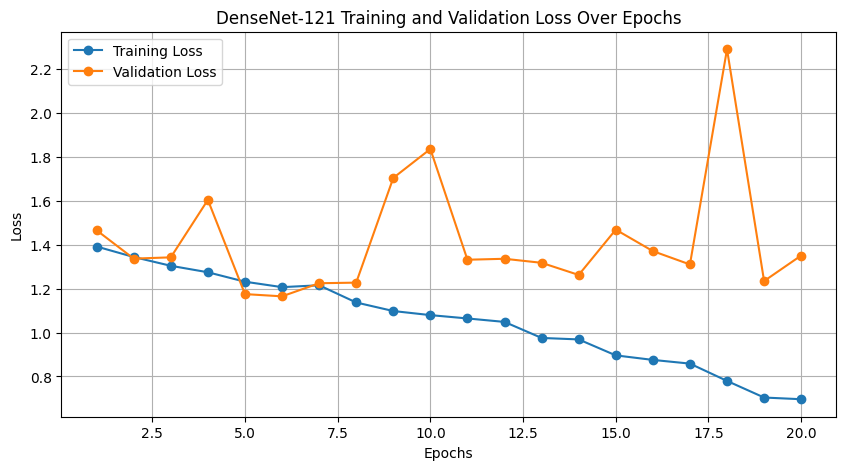

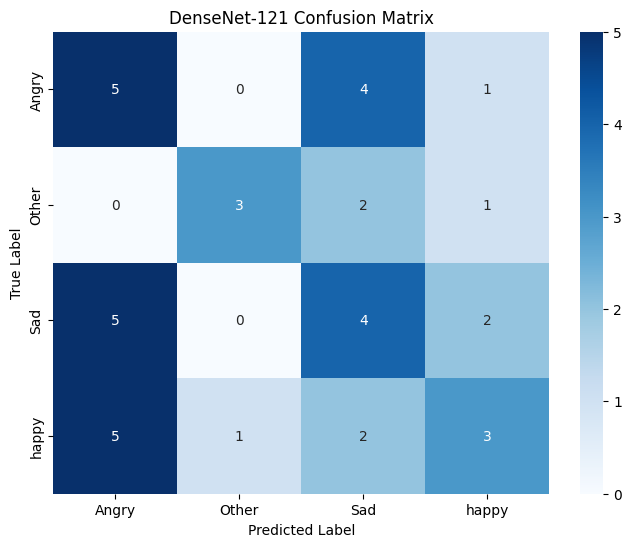

In [9]:
test_loader = dataloaders['test']

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, preds = torch.max(outputs, 1)

        # Move back to CPU and convert to numpy arrays for sklearn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
conf_matrix = confusion_matrix(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall: {recall:.4f}")
print(f"Mean F1-Score: {f1:.4f}")

plt.figure(figsize=(10, 5))
epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet-121 Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DenseNet-121 Confusion Matrix')
plt.show()

In [10]:
loader, classes = get_dataloaders(DataLoaderConfig())
train_loader = loader['train']
val_loader = loader['valid']
test_loader = loader['test']

	New best TL model @ epoch 1: val_loss=1.2493, val_acc=30.56%
[TL] Epoch 1/10 lr=1.00e-03 train_loss=1.3334 train_acc=38.30% val_loss=1.2493 val_acc=30.56%
	New best TL model @ epoch 2: val_loss=1.0930, val_acc=41.67%
[TL] Epoch 2/10 lr=1.00e-03 train_loss=1.1628 train_acc=50.90% val_loss=1.0930 val_acc=41.67%
	New best TL model @ epoch 3: val_loss=1.0899, val_acc=44.44%
[TL] Epoch 3/10 lr=1.00e-03 train_loss=1.1121 train_acc=52.20% val_loss=1.0899 val_acc=44.44%
	New best TL model @ epoch 4: val_loss=1.0715, val_acc=38.89%
[TL] Epoch 4/10 lr=1.00e-03 train_loss=1.0521 train_acc=58.10% val_loss=1.0715 val_acc=38.89%
[TL] Epoch 5/10 lr=1.00e-03 train_loss=0.9973 train_acc=59.00% val_loss=1.1085 val_acc=38.89%
[TL] Epoch 6/10 lr=1.00e-03 train_loss=0.9496 train_acc=61.60% val_loss=1.1834 val_acc=38.89%
[TL] Epoch 7/10 lr=5.00e-04 train_loss=0.9657 train_acc=61.80% val_loss=1.1029 val_acc=41.67%
[TL] Epoch 8/10 lr=5.00e-04 train_loss=0.9218 train_acc=64.70% val_loss=1.0791 val_acc=41.67%


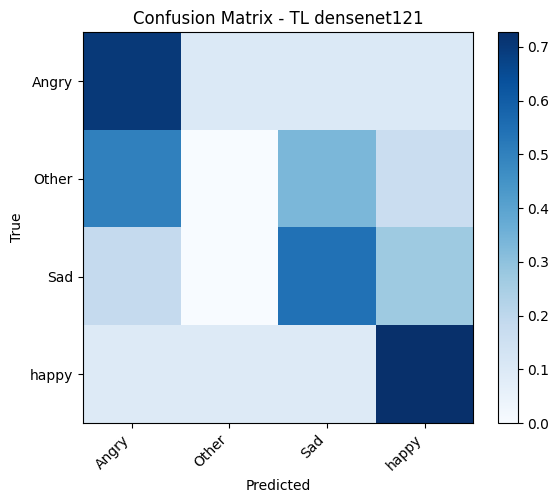

In [11]:
tl_model_name = "densenet121"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tl_epochs = 10

tl_best_ckpt = os.path.join("models", f"best_tl_{tl_model_name}.pth")
os.makedirs("models", exist_ok=True)

# pretrained DenseNet121
tl_model = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# replace classifier
tl_model.classifier = nn.Linear(
    tl_model.classifier.in_features,
    len(class_names)
)

# freeze all pretrained layers
for p in tl_model.parameters():
    p.requires_grad = False

# train only classifier
for p in tl_model.classifier.parameters():
    p.requires_grad = True

tl_model = tl_model.to(device)

tl_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

tl_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tl_optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

# ---- train + cache best checkpoint ----
best_val = float("inf")
for epoch in range(tl_epochs):
    tr_loss, tr_acc = train_one_epoch(tl_model, train_loader, tl_optimizer, device)
    va_loss, va_acc = evaluate_one_epoch(tl_model, val_loader, device)
    tl_scheduler.step(va_loss)

    if va_loss < best_val:
        best_val = va_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": tl_model.state_dict(),
                "val_loss": va_loss,
                "val_acc": va_acc,
                "classes": class_names,
            },
            tl_best_ckpt,
        )
        print(f"\tNew best TL model @ epoch {epoch+1}: val_loss={va_loss:.4f}, val_acc={va_acc:.2f}%")

    print(
        f"[TL] Epoch {epoch+1}/{tl_epochs} "
        f"lr={tl_optimizer.param_groups[0]['lr']:.2e} "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%"
    )

print(f"Best TL checkpoint: {tl_best_ckpt} (val_loss={best_val:.4f})")

# ---- load best + evaluate on test ----
ckpt = torch.load(tl_best_ckpt, map_location=device)
tl_model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded TL checkpoint: {tl_best_ckpt} (val_loss={ckpt.get('val_loss')}, val_acc={ckpt.get('val_acc')})")

metrics_tl = report_classification_metrics(
    tl_model,
    test_loader,
    device,
    class_names=class_names,
    title=f"TL {tl_model_name}",
    plot_confusion_matrix=True,
    normalize_confusion_matrix="true",
)

## Reference
https://arxiv.org/pdf/1608.06993